## 🧪 Cài đặt thư viện cần thiết

In [1]:
!pip install ultralytics==8.2.5
!pip install mlflow
!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install albumentations opencv-python --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.0/755.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

## 🔗 Mount Google Drive và giải nén dữ liệu

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/dispatch/dataset.zip -d /content/dataset
!ls /content/dataset/Detection/


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: /content/dataset/Detection/train/labels/img_001196.txt  
  inflating: /content/dataset/Detection/train/labels/img_001000.txt  
  inflating: /content/dataset/Detection/train/labels/img_000759.txt  
  inflating: /content/dataset/Detection/train/labels/img_000646.txt  
  inflating: /content/dataset/Detection/train/labels/img_000262.txt  
  inflating: /content/dataset/Detection/train/labels/img_000431.txt  
  inflating: /content/dataset/Detection/train/labels/img_001068.txt  
  inflating: /content/dataset/Detection/train/labels/img_000825.txt  
  inflating: /content/dataset/Detection/train/labels/img_000490.txt  
  inflating: /content/dataset/Detection/train/labels/img_000414.txt  
  inflating: /content/dataset/Detection/train/labels/img_001141.txt  
  inflating: /content/dataset/Detection/train/labels/img_000446.txt  
  inflating: /content/dataset/Detection/train/labels/img_000394.txt  
  inflating: /content/dataset/Det

In [3]:
import os
# 🔕 Disable W&B logging before importing Ultralytics
!pip uninstall -y wandb
os.environ["WANDB_DISABLED"] = "true"

Found existing installation: wandb 0.21.0
Uninstalling wandb-0.21.0:
  Successfully uninstalled wandb-0.21.0


📁 Train images: /content/dataset/Detection/train/images
📁 Train labels: /content/dataset/Detection/train/labels
🔢 Classes: ['dish', 'tray']


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


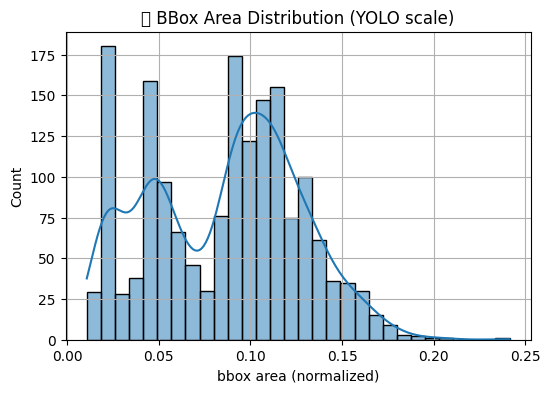

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


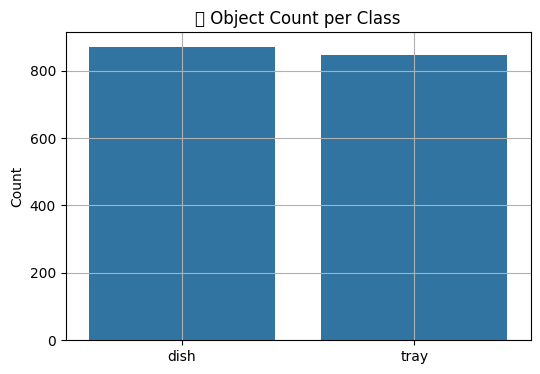

In [4]:
# 📊 Dataset Analysis before Training (Fixed for your structure)
import os
import yaml
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# ========== Load dataset.yaml ==========
dataset_yaml = "/content/dataset/Detection/dataset.yaml"
with open(dataset_yaml, 'r') as f:
    data_cfg = yaml.safe_load(f)

dataset_root = Path(data_cfg['path'])
train_img_dir = dataset_root / data_cfg['train']   # train/images
val_img_dir = dataset_root / data_cfg['val']       # val/images
train_lbl_dir = dataset_root / "train/labels"
val_lbl_dir = dataset_root / "val/labels"
class_names = data_cfg['names']

print(f"📁 Train images: {train_img_dir}")
print(f"📁 Train labels: {train_lbl_dir}")
print(f"🔢 Classes: {class_names}")

# ========== Analyze dataset ==========
def analyze_dataset(img_dir, lbl_dir):
    image_sizes = []
    bbox_areas = []
    class_counts = {i: 0 for i in range(len(class_names))}
    image_exts = [".jpg", ".jpeg", ".png"]

    for img_path in img_dir.glob("*"):
        if img_path.suffix.lower() not in image_exts:
            continue
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        with Image.open(img_path) as img:
            w, h = img.size
            image_sizes.append((w, h))

        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x, y, bw, bh = map(float, parts)
                class_counts[int(cls)] += 1
                bbox_areas.append(bw * bh)  # normalized area

    return image_sizes, bbox_areas, class_counts

# Run analysis on training set
img_sizes, bbox_areas, class_dist = analyze_dataset(train_img_dir, train_lbl_dir)

# ========== Visualize ==========
# BBox area distribution
plt.figure(figsize=(6,4))
sns.histplot(bbox_areas, bins=30, kde=True)
plt.title("📏 BBox Area Distribution (YOLO scale)")
plt.xlabel("bbox area (normalized)")
plt.grid()
plt.show()

# Class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=[class_names[k] for k in class_dist.keys()], y=list(class_dist.values()))
plt.title("📊 Object Count per Class")
plt.ylabel("Count")
plt.grid()
plt.show()



📦 1. Biểu đồ diện tích bounding box (BBox Area Distribution)
Nhận xét:

Khoảng 30–40% các object có diện tích nhỏ hơn 0.05 (trên thang YOLO normalized).

Phân bố không đều, có nhiều đỉnh → có thể do object size thay đổi mạnh giữa các ảnh.

Đề xuất cải thiện:

✅ Tăng imgsz khi training YOLO (ví dụ: từ 640 ➜ 960 hoặc 1088) để giúp YOLO học được các object nhỏ.

✅ Tăng augmentation với các object nhỏ:

mosaic=1.0, copy_paste=0.2, hsv_h=0.015...

❗ Tránh giảm chất lượng ảnh quá mức khi resize.


📦 2. Biểu đồ phân bố object theo class (Object Count per Class)
Nhận xét:

Cân bằng tuyệt vời 🟢: Số lượng dish và tray gần bằng nhau (~850 mỗi class).

Không có class nào bị thiếu hoặc overrepresented.

Hành động:

✅ Không cần oversampling hay re-weighting loss function.

✅ Có thể dùng default class weights khi huấn luyện.

## 🎨 Augmentation sinh vật thể nhỏ mô phỏng thực tế

In [5]:
import albumentations as A
import cv2
from pathlib import Path

# --- AUGMENTATION PIPELINES ---
# Common augment (for images with both dish and tray)
transform = A.Compose([
    A.RandomResizedCrop(size=(640, 640), scale=(0.3, 0.6), ratio=(0.85, 1.25), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(0.2, 0.5), contrast_limit=(0.3, 0.5), p=1.0),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.5),
    A.RandomGamma(gamma_limit=(90, 120), p=0.4),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=0.4),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), p=0.3),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.Perspective(scale=(0.015, 0.04), p=0.5),
    A.Resize(1088, 1088),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

# Aug riêng cho tray
tray_transform = A.Compose([
    A.RandomResizedCrop(size=(640, 640), scale=(0.3, 0.6), ratio=(0.9, 1.4), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(0.2, 0.4), contrast_limit=(0.3, 0.6), p=1.0),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=0.3),
    A.Equalize(p=0.4),
    A.ISONoise(color_shift=(0.01, 0.1), intensity=(0.1, 0.5), p=0.2),
    A.Perspective(scale=(0.05, 0.08), p=0.6),
    A.RandomShadow(p=0.3),
    A.Resize(1088, 1088),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

# Aug riêng cho dish
dish_transform = A.Compose([
    A.RandomResizedCrop(size=(640, 640), scale=(0.4, 0.8), ratio=(0.95, 1.2), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.3), contrast_limit=(-0.2, 0.3), p=0.8),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.6),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    A.Perspective(scale=(0.02, 0.04), p=0.5),
    A.Rotate(limit=15, p=0.4),
    A.HorizontalFlip(p=0.5),
    A.Resize(1088, 1088),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))


/tmp/ipython-input-5-1081385616.py:13: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
/tmp/ipython-input-5-1081385616.py:38: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),


:## 🧪 Sinh ảnh augment kèm nhãn (YOLO) và resize chuẩn

In [6]:
# --- AUGMENTATION FUNCTION ---
def augment_images_with_labels(image_dir, label_dir, output_img_dir, output_lbl_dir, n_aug=2):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)
    output_img_dir = Path(output_img_dir)
    output_lbl_dir = Path(output_lbl_dir)
    output_img_dir.mkdir(parents=True, exist_ok=True)
    output_lbl_dir.mkdir(parents=True, exist_ok=True)

    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
    total_aug = 0

    for img_path in image_paths:
        label_path = label_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        image = cv2.imread(str(img_path))
        h, w = image.shape[:2]

        bboxes = []
        class_labels = []
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x, y, bw, bh = map(float, parts)
                bboxes.append([x, y, bw, bh])
                class_labels.append(int(cls))

        if not bboxes:
            continue

        # --- Chọn transform phù hợp theo class ---
        if all(cls == 0 for cls in class_labels):
            selected_transform = dish_transform
        elif all(cls == 1 for cls in class_labels):
            selected_transform = tray_transform
        else:
            selected_transform = transform  # dùng transform chung cho ảnh mixed

        for i in range(n_aug):
            try:
                augmented = selected_transform(
                    image=image,
                    bboxes=bboxes,
                    class_labels=class_labels
                )
            except Exception as e:
                print(f"❌ Aug failed on {img_path.name}: {e}")
                continue

            aug_img = augmented["image"]
            aug_bboxes = augmented["bboxes"]
            aug_classes = augmented["class_labels"]

            if not aug_bboxes:
                continue

            aug_name = f"{img_path.stem}_aug{i}"
            aug_img_path = output_img_dir / f"{aug_name}.jpg"
            aug_lbl_path = output_lbl_dir / f"{aug_name}.txt"

            cv2.imwrite(str(aug_img_path), aug_img)
            with open(aug_lbl_path, "w") as f:
                for bbox, cls in zip(aug_bboxes, aug_classes):
                    f.write(f"{cls} {' '.join(map(str, bbox))}\n")

            total_aug += 1

    print(f"✅ Đã tạo {total_aug} ảnh augment + nhãn tại {output_img_dir}")


## ▶️ Gọi augment trên thư mục train

In [7]:
augment_images_with_labels(
    image_dir="/content/dataset/Detection/train/images",
    label_dir="/content/dataset/Detection/train/labels",
    output_img_dir="/content/dataset/Detection/train/images_aug",
    output_lbl_dir="/content/dataset/Detection/train/labels_aug",
    n_aug=2
)


✅ Đã tạo 1839 ảnh augment + nhãn tại /content/dataset/Detection/train/images_aug


In [8]:
from pathlib import Path

def check_aug_image_label_match(image_dir, label_dir):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_stems = set(p.stem for p in image_dir.glob("*.jpg")) | set(p.stem for p in image_dir.glob("*.png"))
    label_stems = set(p.stem for p in label_dir.glob("*.txt"))

    matched = image_stems & label_stems
    img_only = image_stems - label_stems
    lbl_only = label_stems - image_stems

    print(f"🧪 Tổng ảnh augment: {len(image_stems)}")
    print(f"🏷️ Tổng nhãn augment: {len(label_stems)}")
    print(f"✅ Khớp đúng: {len(matched)}")
    print(f"⚠️ Ảnh KHÔNG có nhãn: {len(img_only)}")
    if img_only:
        print("  🔸 Ví dụ ảnh thiếu nhãn:")
        for name in list(img_only)[:5]:
            print(f"    ⚠️ {name}.jpg")
    print(f"⚠️ Nhãn KHÔNG có ảnh: {len(lbl_only)}")
    if lbl_only:
        print("  🔸 Ví dụ nhãn thiếu ảnh:")
        for name in list(lbl_only)[:5]:
            print(f"    ⚠️ {name}.txt")

# Kiểm tra trong thư mục augment
check_aug_image_label_match(
    image_dir="/content/dataset/Detection/train/images_aug",
    label_dir="/content/dataset/Detection/train/labels_aug"
)


🧪 Tổng ảnh augment: 1839
🏷️ Tổng nhãn augment: 1839
✅ Khớp đúng: 1839
⚠️ Ảnh KHÔNG có nhãn: 0
⚠️ Nhãn KHÔNG có ảnh: 0


In [9]:
from pathlib import Path
import shutil

base_path = Path("/content/dataset/Detection")

# === 1. Gộp ảnh + nhãn augment và train/labels
aug_img_dir = base_path / "train/images_aug"
aug_lbl_dir = base_path / "train/labels_aug"
train_lbl_dir = base_path / "train/labels"

merged_img_count = 0
merged_lbl_count = 0

if aug_img_dir.exists():
    for file in aug_img_dir.glob("*.[jp][pn]g"):
        shutil.move(str(file), train_img_dir / file.name)
        merged_img_count += 1

if aug_lbl_dir.exists():
    for file in aug_lbl_dir.glob("*.txt"):
        shutil.move(str(file), train_lbl_dir / file.name)
        merged_lbl_count += 1

print(f"✅ Đã gộp {merged_img_count} ảnh và {merged_lbl_count} nhãn augment vào tập train.")

# === 2. Xoá thư mục tạm: ảnh & nhãn augment
temp_dirs = [
    base_path / "train/images_aug",
    base_path / "train/labels_aug"
]

for aug_dir in temp_dirs:
    if aug_dir.exists():
        shutil.rmtree(aug_dir)
        print(f"🧹 Đã xoá thư mục tạm: {aug_dir}")

# === 3. Xoá file cache YOLO nếu có
for subset in ["train", "val"]:
    cache_path = base_path / subset / "images.cache"
    if cache_path.exists():
        cache_path.unlink()
        print(f"🗑️ Đã xoá file cache: {cache_path.name}")


✅ Đã gộp 1839 ảnh và 1839 nhãn augment vào tập train.
🧹 Đã xoá thư mục tạm: /content/dataset/Detection/train/images_aug
🧹 Đã xoá thư mục tạm: /content/dataset/Detection/train/labels_aug


In [10]:
from pathlib import Path

def check_image_label_validity(image_dir, label_dir):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    imgs = set(p.stem for p in image_dir.glob("*.jpg")) | set(p.stem for p in image_dir.glob("*.png"))
    lbls = set(p.stem for p in label_dir.glob("*.txt"))

    matched = imgs & lbls
    unmatched = imgs - lbls

    print(f"\n📁 📦 Tổng hợp kiểm tra tại {image_dir.parent.name.upper()}")
    print(f"📸 Tổng số ảnh: {len(imgs)}")
    print(f"🏷️  Tổng số file nhãn: {len(lbls)}")
    print(f"✅  Ảnh có nhãn hợp lệ: {len(matched)}")
    print(f"⚠️  Ảnh KHÔNG có nhãn: {len(unmatched)}")

    if unmatched:
        print("🧐 Một số ảnh thiếu nhãn:")
        for name in list(unmatched)[:5]:
            print(f"  ⚠️ {name}.jpg")

# Áp dụng cho train và val
check_image_label_validity(
    image_dir="/content/dataset/Detection/train/images",
    label_dir="/content/dataset/Detection/train/labels"
)

check_image_label_validity(
    image_dir="/content/dataset/Detection/val/images",
    label_dir="/content/dataset/Detection/val/labels"
)



📁 📦 Tổng hợp kiểm tra tại TRAIN
📸 Tổng số ảnh: 2879
🏷️  Tổng số file nhãn: 2879
✅  Ảnh có nhãn hợp lệ: 2879
⚠️  Ảnh KHÔNG có nhãn: 0

📁 📦 Tổng hợp kiểm tra tại VAL
📸 Tổng số ảnh: 261
🏷️  Tổng số file nhãn: 261
✅  Ảnh có nhãn hợp lệ: 261
⚠️  Ảnh KHÔNG có nhãn: 0


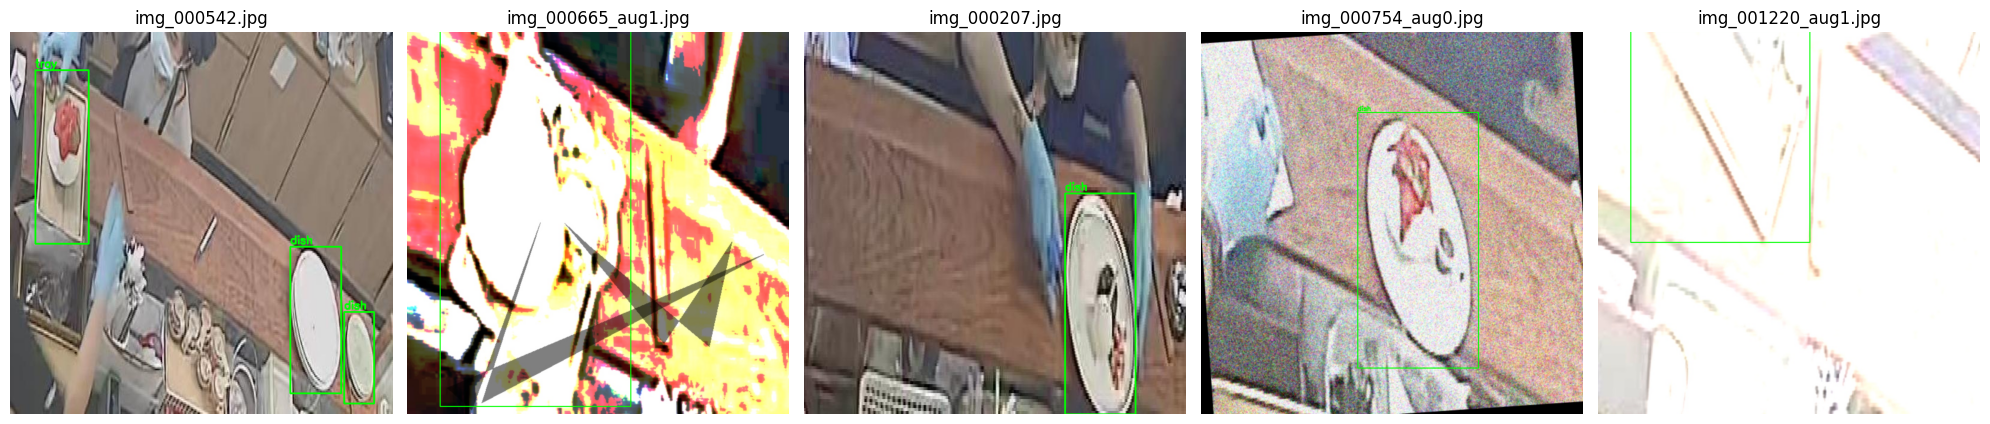

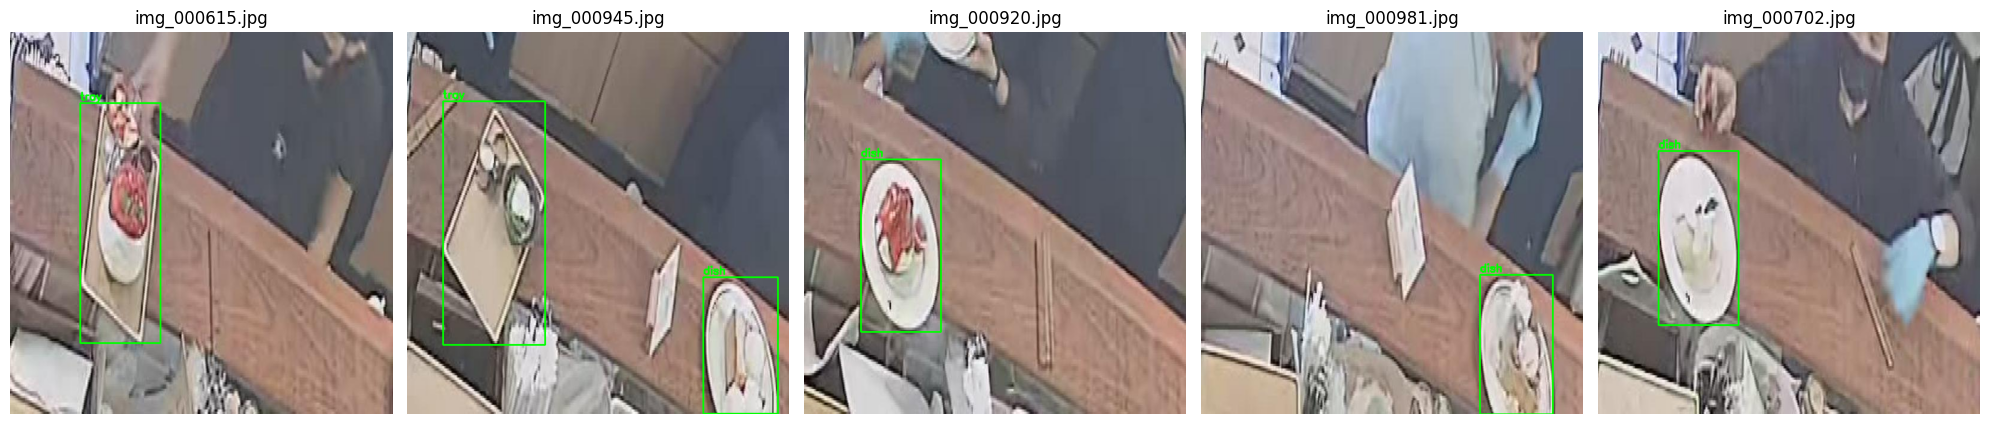

In [11]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

def draw_bbox_yolo(image_path, label_path, class_names=None):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if not label_path.exists():
        return img  # no bbox

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, x_center, y_center, bw, bh = map(float, parts)
            x1 = int((x_center - bw / 2) * w)
            y1 = int((y_center - bh / 2) * h)
            x2 = int((x_center + bw / 2) * w)
            y2 = int((y_center + bh / 2) * h)
            color = (0, 255, 0)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = class_names[int(cls_id)] if class_names else str(int(cls_id))
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img

def visualize_random_bboxes(image_dir, label_dir, n=5, class_names=None):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
    image_paths = [p for p in image_paths if (label_dir / f"{p.stem}.txt").exists()]
    if not image_paths:
        print("⚠️ Không tìm thấy ảnh nào có nhãn hợp lệ.")
        return

    selected = random.sample(image_paths, min(n, len(image_paths)))

    fig, axes = plt.subplots(1, len(selected), figsize=(20, 6))
    if len(selected) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, selected):
        label_path = label_dir / f"{img_path.stem}.txt"
        img = draw_bbox_yolo(img_path, label_path, class_names)
        ax.imshow(img)
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# 🔍 Gọi cho tập train
visualize_random_bboxes(
    image_dir="/content/dataset/Detection/train/images",
    label_dir="/content/dataset/Detection/train/labels",
    n=5,
    class_names=["dish", "tray"]
)

# 🔍 Gọi cho tập val
visualize_random_bboxes(
    image_dir="/content/dataset/Detection/val/images",
    label_dir="/content/dataset/Detection/val/labels",
    n=5,
    class_names=["dish", "tray"]
)

## 🚀 Huấn luyện YOLOv8 tối ưu cho object nhỏ

In [13]:
from ultralytics import YOLO
import mlflow
import torch

mlflow.set_tracking_uri("https://e52d4a09300f.ngrok-free.app")
mlflow.set_experiment("dispatch-detection")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_params = {
    "model": "yolov8s",
    "epochs": 71,
    "imgsz": 1088,
    "batch": 8,
    "patience": 20,
    "hsv_h": 0.015,
    "copy_paste": 0.4,
    "mosaic": 1.0,
    "scale": 0.5,
    "translate": 0.2,
    "perspective": 0.001,
    "fliplr": 0.5,
    "flipud": 0.0,
    "degrees": 0.0,
    "note": "augment riêng cho dish, tray và cả dish + tray, tiếp tục với epoch 71"
}

with mlflow.start_run(run_name="yolov8s_object_small"):
    mlflow.log_params(train_params)

    ### new training  ###
    # model = YOLO("yolov8s.pt")

    ### retraining   ###
    model = YOLO("/content/runs/detect/yolov8s_dispatch_augments/weights/last.pt")

    results = model.train(
        data="/content/dataset/Detection/dataset.yaml",
        device=device,
        # name="yolov8s_dispatch_smallobj",
        name="yolov8s_dispatch_augments_epoch_71",  # 👈 tránh ghi đè vào thư mục cũ
        # resume=True, ## Cần thiết cho retrain
        **{k: v for k, v in train_params.items() if k not in ["model", "note"]}
    )

    if hasattr(results, "metrics"):
        mlflow.log_metrics({
            "map50": results.metrics.box.map50,
            "map": results.metrics.box.map,
            "precision": results.metrics.box.precision,
            "recall": results.metrics.box.recall
        })


New https://pypi.org/project/ultralytics/8.3.166 available 😃 Update with 'pip install -U ultralytics'


/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


engine/trainer: task=detect, mode=train, model=/content/runs/detect/yolov8s_dispatch_augments/weights/last.pt, data=/content/dataset/Detection/dataset.yaml, epochs=71, time=None, patience=20, batch=8, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=yolov8s_dispatch_augments_epoch_71, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True,

100%|██████████| 755k/755k [00:00<00:00, 21.7MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

...

      29/71       5.5G      1.036     0.8519      1.327         19       1088: 100%|██████████| 360/360 [02:47<00:00,  2.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:05<00:00,  3.25it/s]


                   all        261        374      0.989      0.972      0.993      0.855
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 9, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

29 epochs completed in 1.425 hours.
Optimizer stripped from runs/detect/yolov8s_dispatch_augments_epoch_71/weights/last.pt, 22.6MB
Optimizer stripped from runs/detect/yolov8s_dispatch_augments_epoch_71/weights/best.pt, 22.6MB

Validating runs/detect/yolov8s_dispatch_augments_epoch_71/weights/best.pt...
Ultralytics YOLOv8.2.5 🚀 Python-3.11.13 torch-2.5.1+cu118 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11126358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:08<00:00,  1.93it/s]


                   all        261        374      0.975       0.97      0.988      0.863
                  dish        261        175      0.951      0.983      0.992      0.871
                  tray        261        199          1      0.957      0.985      0.854
Speed: 0.7ms preprocess, 13.6ms inference, 0.0ms loss, 5.1ms postprocess per image
Results saved to runs/detect/yolov8s_dispatch_augments_epoch_71
🏃 View run yolov8s_object_small at: https://e52d4a09300f.ngrok-free.app/#/experiments/579057812200506208/runs/3ab8abb3cccb4696a4a8d707d1227e47
🧪 View experiment at: https://e52d4a09300f.ngrok-free.app/#/experiments/579057812200506208


MlflowException: API request to https://e52d4a09300f.ngrok-free.app/api/2.0/mlflow-artifacts/artifacts/579057812200506208/3ab8abb3cccb4696a4a8d707d1227e47/artifacts/weights/best.pt failed with exception HTTPSConnectionPool(host='e52d4a09300f.ngrok-free.app', port=443): Max retries exceeded with url: /api/2.0/mlflow-artifacts/artifacts/579057812200506208/3ab8abb3cccb4696a4a8d707d1227e47/artifacts/weights/best.pt (Caused by ResponseError('too many 500 error responses'))

In [14]:
!zip -r runs_yolo.zip runs/
from google.colab import files
files.download("runs_yolo.zip")

  adding: runs/ (stored 0%)
  adding: runs/detect/ (stored 0%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/ (stored 0%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/labels.jpg (deflated 25%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/weights/ (stored 0%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/weights/best.pt (deflated 31%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/weights/last.pt (deflated 31%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/args.yaml (deflated 53%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/results.csv (deflated 85%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/train_batch0.jpg (deflated 8%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/events.out.tfevents.1752459229.f0497d2f8083.284.1 (deflated 90%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/labels_correlogram.jpg (deflated 39%)
  adding: runs/detect/yolov8s_dispatch_smallobj_resume/train_batch2.jpg (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Lưu tạm /content/runs/ vào /content/drive/MyDrive/dispatch/runs để ngày mai train tiếp

In [15]:
import shutil

# Tạo thư mục đích nếu chưa có
!mkdir -p /content/drive/MyDrive/dispatch

# Sao chép toàn bộ thư mục runs/ vào Drive
shutil.copytree('/content/runs', '/content/drive/MyDrive/dispatch/runs', dirs_exist_ok=True)
print("✅ Sao chép runs/ vào Drive thành công.")


✅ Sao chép runs/ vào Drive thành công.


Copy thư mục runs/ từ Drive ngược lại Colab để train tiếp

In [12]:
import shutil

# Xóa thư mục runs/ cũ nếu có (để tránh trùng lặp hoặc lỗi)
!rm -rf /content/runs

# Copy từ Drive ngược lại vào Colab
shutil.copytree('/content/drive/MyDrive/dispatch/runs', '/content/runs', dirs_exist_ok=True)
print("✅ Khôi phục runs/ từ Drive vào Colab thành công.")


✅ Khôi phục runs/ từ Drive vào Colab thành công.
